# 01 · EDA por edición y conjunto

EDA de las tablas maestras sin imputar de `00_pipeline_multiedicion_PISA.ipynb` (`data/intermediate/datos_anuales/`): primero **cada edición por separado** (2012, 2015, 2018, 2022) y después **todas juntas**.

Se trabaja con una **vista** de cada tabla (ids, pesos, `PV` y el contexto curado), no con las 1.000+ columnas. Los nulos se dejan tal cual: no se imputa nada.

## 0. Configuración

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))   # para importar `src`

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import plotly.express as px
import plotly.io as pio
from IPython.display import display, Markdown

from src.pisa_pipeline import (
    EDICIONES_PISA, DOMINIOS, COLUMNAS_CONTEXTO_ESTUDIANTE, COLUMNAS_CONTEXTO_COLEGIO,
    columnas_pv, rutas_datos_anuales, leer_vista_estudiantes, leer_vista_colegios,
    porcentaje_nulos, porcentaje_nulos_por_pais, agregar_pv_por_pais,
)
from src.utils_pisa import establecer_semilla

establecer_semilla()

# Plotly desde CDN: si no, cada figura incrusta la librería entera y el notebook pesa decenas de MB
pio.renderers.default = 'notebook_connected'

✅ Semillas del proyecto establecidas con éxito (seed=42).


In [2]:
EDICIONES = [2012, 2015, 2018, 2022]
RUTA_INTERMEDIOS = '../../data/intermediate'
SEMILLA = 42
UMBRAL_NULOS = 5.0        # % de nulos a partir del cual se revisa el desglose por país
N_MUESTRA_MSNO = 20_000   # alumnos que se muestrean para los gráficos de nulos (la tabla completa es lenta)

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Vistas de análisis de cada edición, leídas del parquet sin imputar
estudiantes, colegios = {}, {}
for año in EDICIONES:
    ruta_est, ruta_col = rutas_datos_anuales(RUTA_INTERMEDIOS, año)
    estudiantes[año] = leer_vista_estudiantes(ruta_est)
    colegios[año] = leer_vista_colegios(ruta_col)

pd.DataFrame({
    año: {'alumnos': len(estudiantes[año]), 'centros': len(colegios[año]),
          'países': estudiantes[año]['CNT'].nunique(),
          'cols alumnos (vista)': estudiantes[año].shape[1], 'cols centros (vista)': colegios[año].shape[1]}
    for año in EDICIONES
})

,2012,2015,2018,2022
alumnos,290158,238452,269587,268610
centros,11725,9076,10366,10131
países,33,33,33,33
cols alumnos (vista),40,53,54,57
cols centros (vista),9,10,10,11


## 1. EDA por edición

`eda_edicion(año)` genera, para una edición: dimensiones y nulos, nulos por país, patrón de nulos, distribución de los índices, sanity check de pesos, correlaciones, ¿la no-respuesta es señal?, rendimiento por país y estructura multinivel. Guarda el rendimiento y la varianza para la comparación conjunta.

In [3]:
rendimiento_por_edicion = []   # filas (EDICION, CNT, DOMINIO, media_pv), para la sección 2
varianza_por_edicion = {}      # % de varianza entre países / escuelas / alumnos


def eda_edicion(año):
    est, col = estudiantes[año], colegios[año]
    dominio = EDICIONES_PISA[año]['dominio_principal']
    contexto = [c for c in COLUMNAS_CONTEXTO_ESTUDIANTE if c in est.columns]
    contexto_col = [c for c in COLUMNAS_CONTEXTO_COLEGIO if c in col.columns]
    pv_dominio = [c for c in columnas_pv(dominio) if c in est.columns]
    perf = est[pv_dominio].mean(axis=1)   # rendimiento del alumno en el dominio principal

    display(Markdown(f'### PISA {año} (dominio principal: {dominio})'))

    # 1. Dimensiones y nulos
    print(f'{len(est):,} alumnos | {len(col):,} centros | {est["CNT"].nunique()} países')
    nulos_est = porcentaje_nulos(est[contexto])
    nulos_col = porcentaje_nulos(col[contexto_col])
    display(pd.concat([nulos_est[nulos_est > 0].rename('% nulos alumnos'),
                       nulos_col[nulos_col > 0].rename('% nulos centros')], axis=1).round(1))

    # 2. Países con más nulos en las columnas con muchos nulos
    resumen = {}
    for tabla, df, nulos in (('alumnos', est, nulos_est), ('centros', col, nulos_col)):
        for c in nulos[nulos > UMBRAL_NULOS].index:
            top = porcentaje_nulos_por_pais(df, c).head(5)
            resumen[(tabla, c)] = ', '.join(f'{r[0]} ({r[1]:.0f}%)' for r in top.itertuples(index=False))
    if resumen:
        display(pd.Series(resumen, name='países con más nulos'))

    # 3. Patrón de nulos (muestra de alumnos)
    muestra = est[contexto].sample(min(N_MUESTRA_MSNO, len(est)), random_state=SEMILLA)
    msno.matrix(muestra, figsize=(12, 4))
    plt.title(f'Matriz de nulos — PISA {año} (muestra)')
    plt.show()
    msno.heatmap(muestra, figsize=(9, 7))
    plt.title(f'Correlación de nulidad — PISA {año}')
    plt.show()
    msno.dendrogram(muestra, figsize=(10, 5))
    plt.title(f'Bloques de nulidad conjunta — PISA {año}')
    plt.show()

    # 4. Distribución de los índices de contexto (HISEI, 0-100, aparte)
    indices = [c for c in contexto if c != 'HISEI']
    n_filas = -(-len(indices) // 4)
    fig, axes = plt.subplots(n_filas, 4, figsize=(16, 3 * n_filas))
    for ax, c in zip(axes.flat, indices):
        est[c].dropna().hist(bins=50, ax=ax)
        ax.set_title(c)
    for ax in axes.flat[len(indices):]:
        ax.axis('off')
    plt.suptitle(f'Índices de contexto — PISA {año}')
    plt.tight_layout()
    plt.show()

    # 5. Sanity check de los pesos: SENWT debe sumar 5000 por país
    sumas = est.groupby('CNT')['SENWT'].sum()
    print(f'Suma de SENWT por país: mín {sumas.min():.2f}, máx {sumas.max():.2f} (esperado 5000)')
    display(est[['W_FSTUWT', 'SENWT']].describe())

    # 6. Correlación entre contexto y rendimiento (media de los PV de cada dominio)
    df_corr = est[contexto].copy()
    for d in DOMINIOS:
        pv = [c for c in columnas_pv(d) if c in est.columns]
        df_corr[d] = est[pv].mean(axis=1)
    corr = df_corr.corr()
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr)))
    ax.set_yticklabels(corr.columns)
    plt.colorbar(im, ax=ax, label='correlación de Pearson')
    plt.title(f'Contexto y rendimiento — PISA {año}')
    plt.tight_layout()
    plt.show()

    # 7. ¿La no-respuesta es señal? Rendimiento de quien tiene el dato frente a quien no
    filas = []
    for c in nulos_est[nulos_est > 0].index:
        falta = est[c].isna()
        filas.append({'variable': c, 'perf_con_dato': perf[~falta].mean(), 'perf_sin_dato': perf[falta].mean(),
                      'diferencia': perf[~falta].mean() - perf[falta].mean()})
    if filas:
        display(pd.DataFrame(filas).set_index('variable').sort_values('diferencia', key=abs, ascending=False))

    # 8. Rendimiento medio por país y dominio (PV promediados por alumno, ponderados por W_FSTUWT)
    filas = []
    for d in DOMINIOS:
        for pais, media in agregar_pv_por_pais(est, d).items():
            filas.append({'EDICION': año, 'CNT': pais, 'DOMINIO': d, 'media_pv': media})
    df_rend = pd.DataFrame(filas)
    rendimiento_por_edicion.append(df_rend)
    fig = px.bar(df_rend.sort_values('media_pv', ascending=False), x='CNT', y='media_pv', color='DOMINIO',
                 barmode='group', title=f'Rendimiento medio por país y dominio — PISA {año}',
                 labels={'media_pv': 'Puntuación media (PV)', 'CNT': 'País'})
    fig.show()

    # 9. Estructura multinivel (sumas de cuadrados anidadas, sin ponderar)
    d = pd.DataFrame({'CNT': est['CNT'], 'esc': est['CNTSCHID'], 'perf': perf}).dropna()
    media_global = d['perf'].mean()
    media_pais = d.groupby('CNT')['perf'].transform('mean')
    media_esc = d.groupby(['CNT', 'esc'])['perf'].transform('mean')
    ss_total = ((d['perf'] - media_global) ** 2).sum()
    varianza_por_edicion[año] = pd.Series({
        'Entre países': ((media_pais - media_global) ** 2).sum() / ss_total * 100,
        'Entre escuelas (dentro de país)': ((media_esc - media_pais) ** 2).sum() / ss_total * 100,
        'Entre alumnos (dentro de escuela)': ((d['perf'] - media_esc) ** 2).sum() / ss_total * 100,
    })
    print('Varianza del rendimiento (%):')
    display(varianza_por_edicion[año].round(1).to_frame(f'PISA {año}').T)

## 1.1 PISA 2012

### PISA 2012 (dominio principal: MATH)

290,158 alumnos | 11,725 centros | 33 países


,% nulos alumnos,% nulos centros
OUTHOURS,35.60,NaN
BELONG,35.00,NaN
DISCLIMA,34.90,NaN
ANXMAT,34.90,NaN
TEACHSUP,34.70,NaN
MATHEFF,34.70,NaN
HISEI_TREND,5.00,NaN
HISEI,4.90,NaN
PAREDINT_TREND,4.00,NaN
PAREDINT,3.20,NaN


alumnos  OUTHOURS       DEU (46%), ISR (39%), ISL (37%), FRA (37%), NL...
         BELONG         DEU (45%), ISR (38%), BEL (37%), SWE (36%), SV...
         DISCLIMA       DEU (45%), ISR (37%), NLD (37%), BEL (37%), SV...
         ANXMAT         DEU (45%), ISR (37%), NLD (37%), BEL (37%), SV...
         TEACHSUP       DEU (45%), NLD (37%), BEL (37%), ISR (36%), SV...
         MATHEFF        DEU (44%), ISR (37%), ISL (36%), SVN (36%), NL...
         HISEI_TREND    AUT (100%), DEU (19%), JPN (9%), CAN (6%), ISL...
centros  PROPMATH       ISL (28%), IRL (26%), AUT (25%), ISR (23%), NL...
         STRATIO        NLD (20%), ISR (17%), DNK (17%), IRL (17%), IS...
Name: países con más nulos, dtype: object

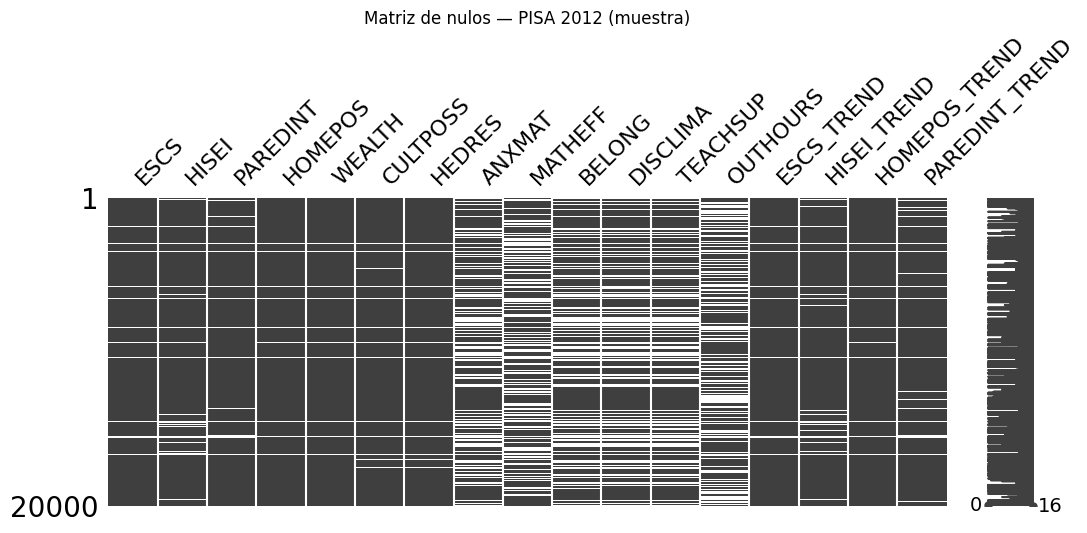

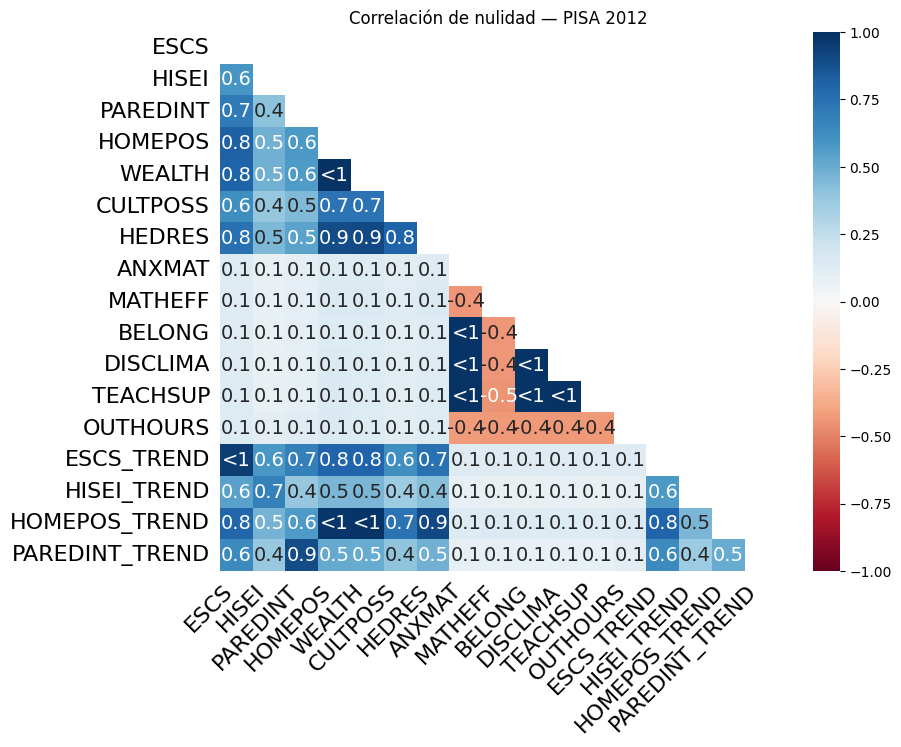

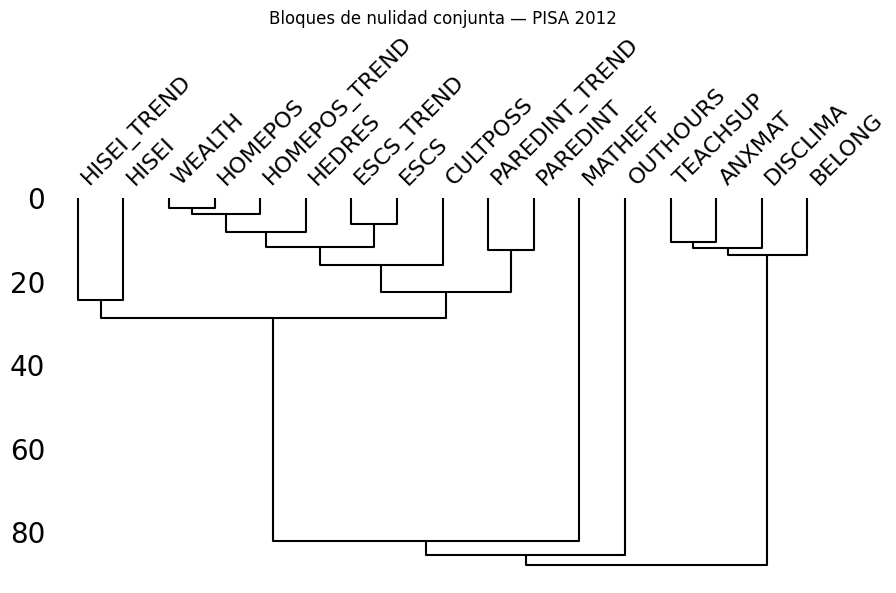

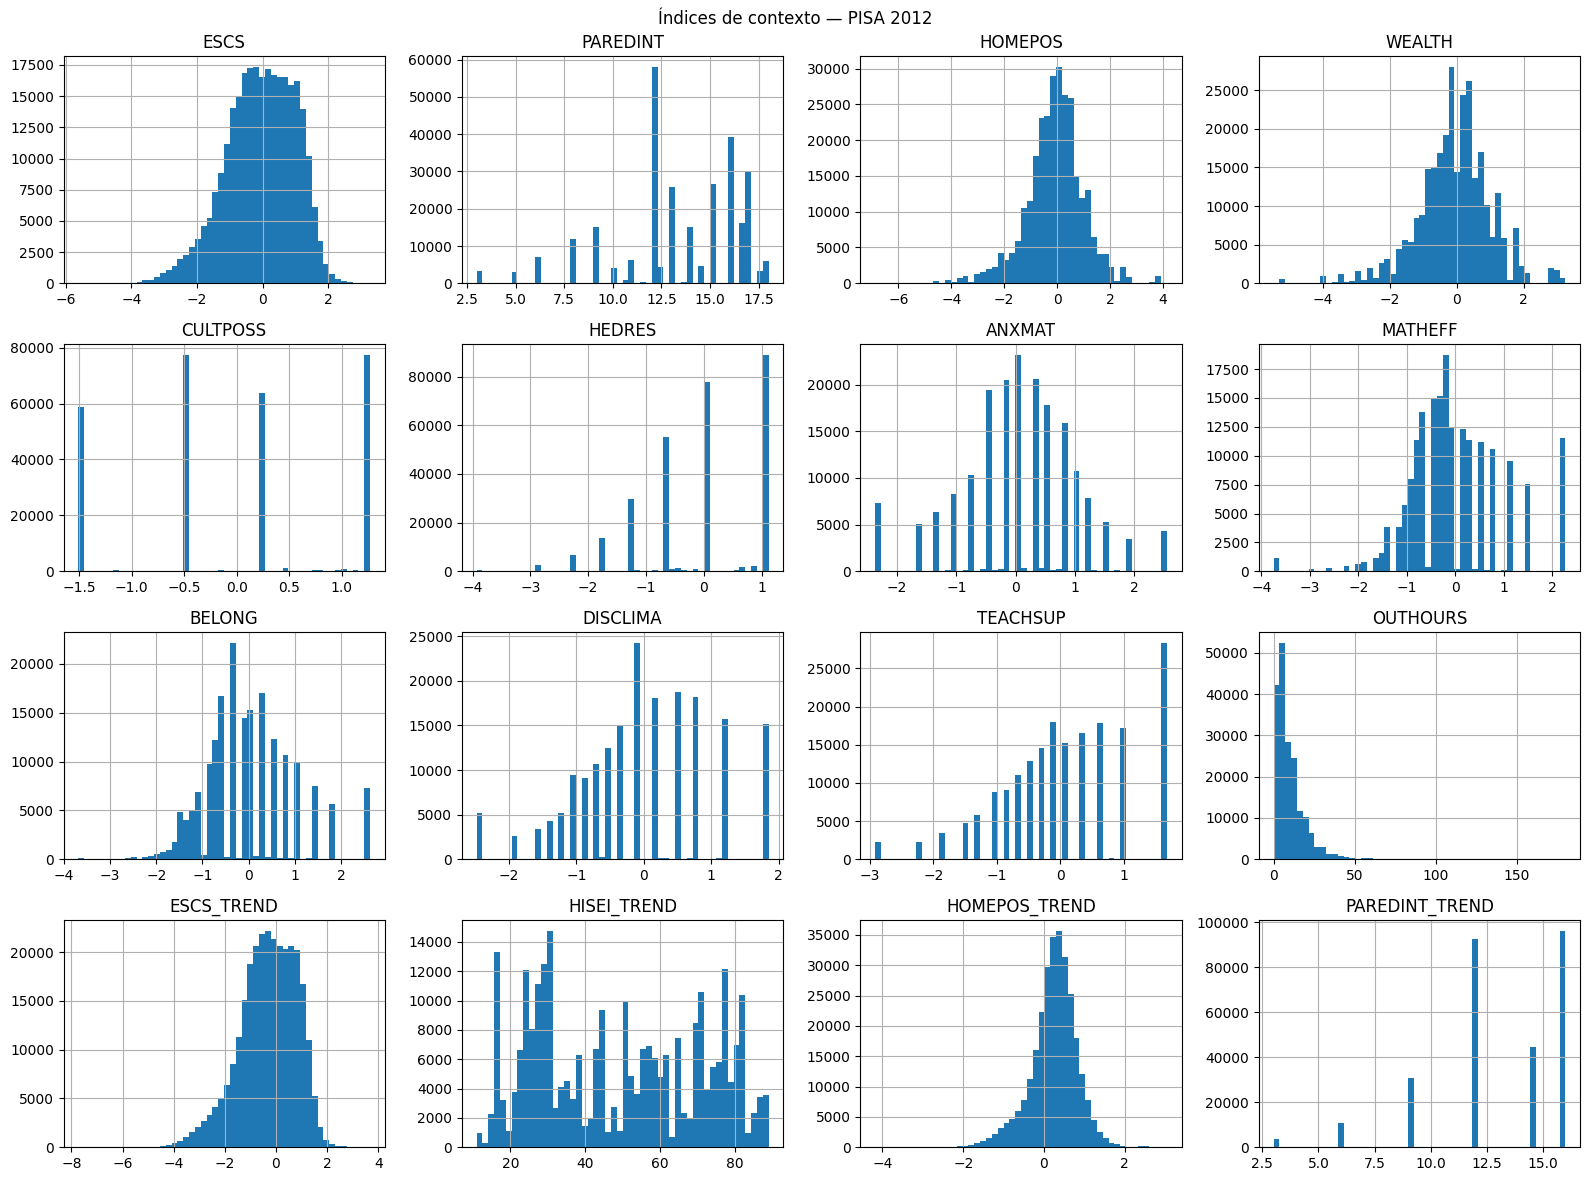

Suma de SENWT por país: mín 5000.00, máx 5000.00 (esperado 5000)


,W_FSTUWT,SENWT
count,290158.00,290158.00
mean,45.28,0.57
std,107.27,0.50
min,1.00,0.01
25%,6.58,0.10
50%,15.56,0.46
75%,34.34,0.96
max,2597.88,8.22


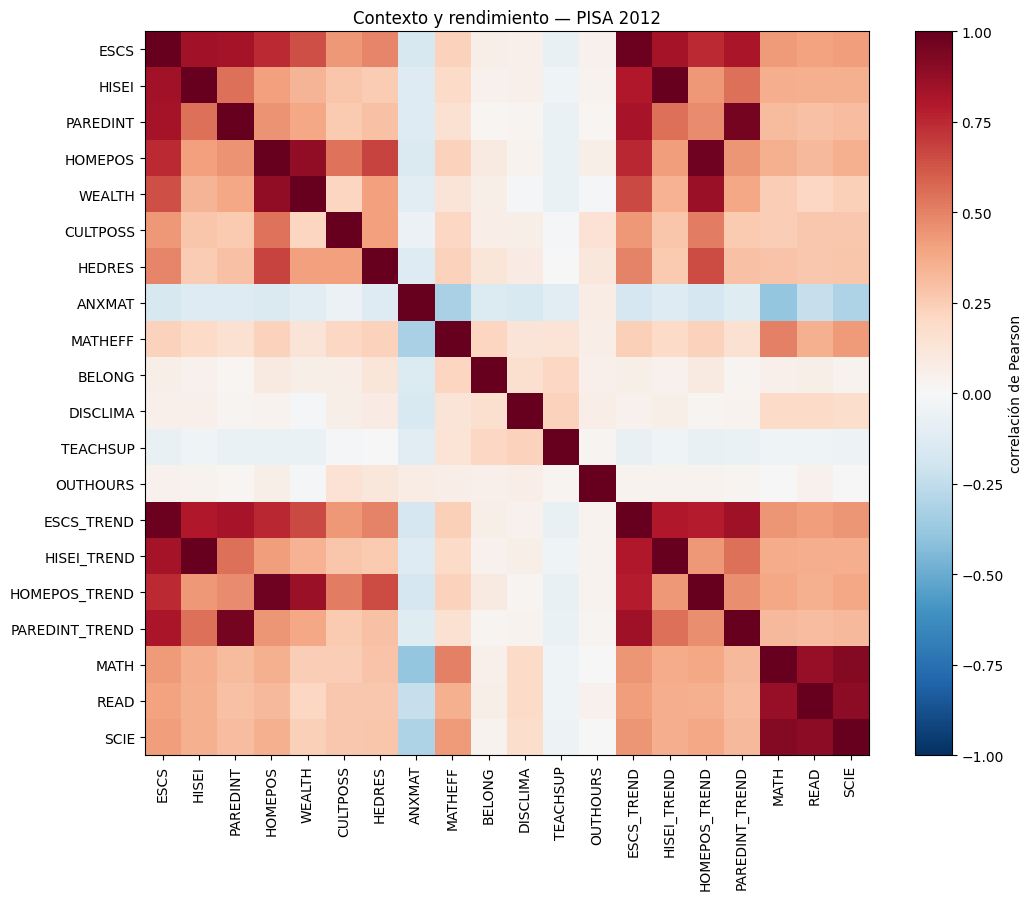

,perf_con_dato,perf_sin_dato,diferencia
variable,,,
CULTPOSS,490.39,411.40,78.99
HEDRES,489.45,418.97,70.47
ESCS,489.53,421.52,68.01
ESCS_TREND,489.51,421.56,67.95
HISEI,491.59,426.15,65.45
HOMEPOS_TREND,489.22,424.15,65.06
HOMEPOS,489.19,424.34,64.84
WEALTH,489.20,425.19,64.01
PAREDINT,490.31,428.92,61.39


Varianza del rendimiento (%):


,Entre países,Entre escuelas (dentro de país),Entre alumnos (dentro de escuela)
PISA 2012,11.70,35.30,53.10


In [4]:
eda_edicion(2012)

## 1.2 PISA 2015

### PISA 2015 (dominio principal: SCIE)

238,452 alumnos | 9,076 centros | 33 países


,% nulos alumnos,% nulos centros
OUTHOURS,15.80,NaN
TEACHSUP,14.80,NaN
HISEI,8.70,NaN
HISEI_TREND,7.00,NaN
BELONG,6.00,NaN
PAREDINT_TREND,3.80,NaN
CULTPOSS,3.40,NaN
PAREDINT,3.30,NaN
ESCS,2.30,NaN
ESCS_TREND,2.30,NaN


alumnos  OUTHOURS       SVN (31%), AUS (29%), DEU (27%), CAN (26%), JP...
         TEACHSUP       SVN (64%), DEU (31%), PRT (29%), AUT (23%), AU...
         HISEI          DEU (18%), DNK (15%), GBR (13%), TUR (13%), SV...
         HISEI_TREND    DEU (17%), DNK (12%), GBR (12%), CAN (11%), JP...
         BELONG         ISR (100%), DEU (14%), DNK (7%), SVK (5%), BEL...
centros  SCHLTYPE       ISR (100%), BEL (70%), NLD (42%), ITA (30%), G...
         STRATIO        NLD (51%), ITA (32%), GBR (31%), DEU (26%), DN...
         STAFFSHORT     NLD (36%), ITA (31%), GBR (25%), DEU (24%), DN...
         EDUSHORT       NLD (36%), ITA (31%), GBR (26%), NZL (23%), DN...
         CLSIZE         NLD (32%), ITA (28%), PRT (23%), GBR (22%), DE...
Name: países con más nulos, dtype: object

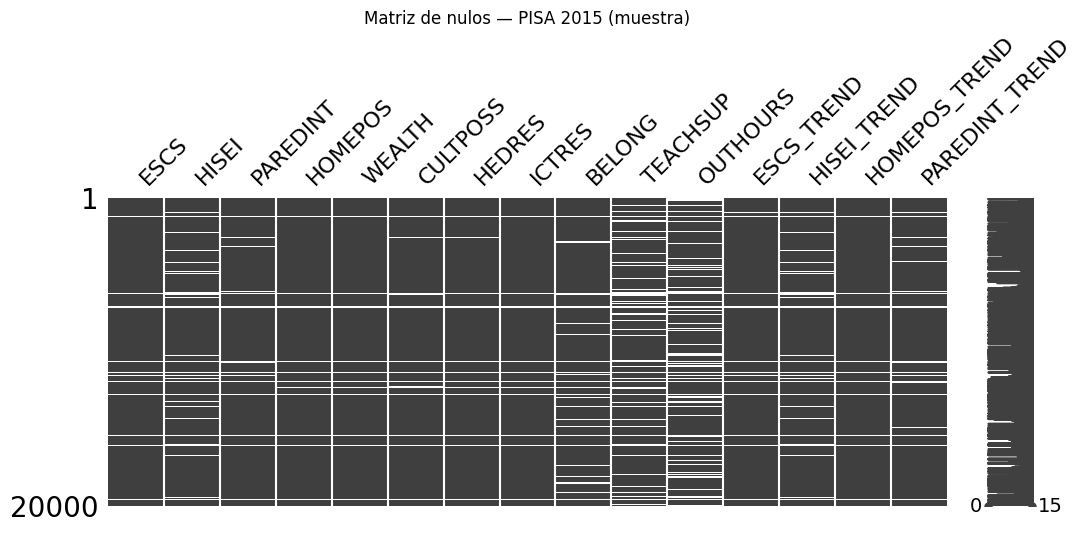

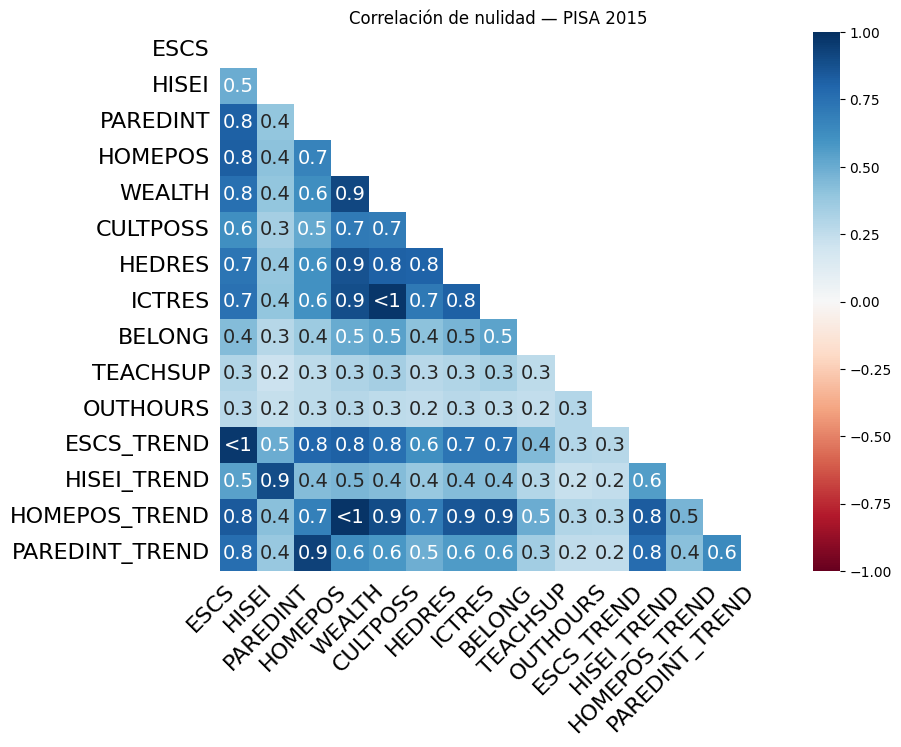

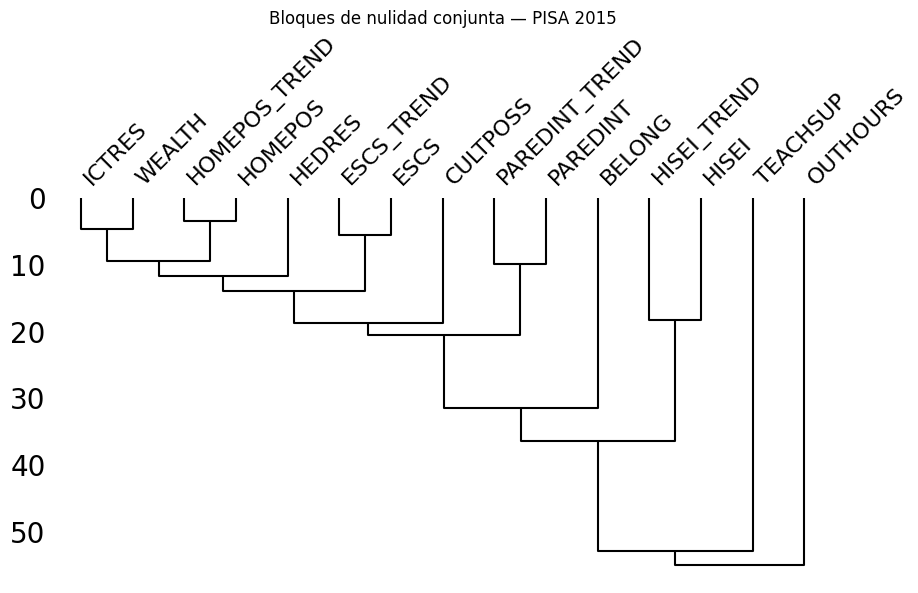

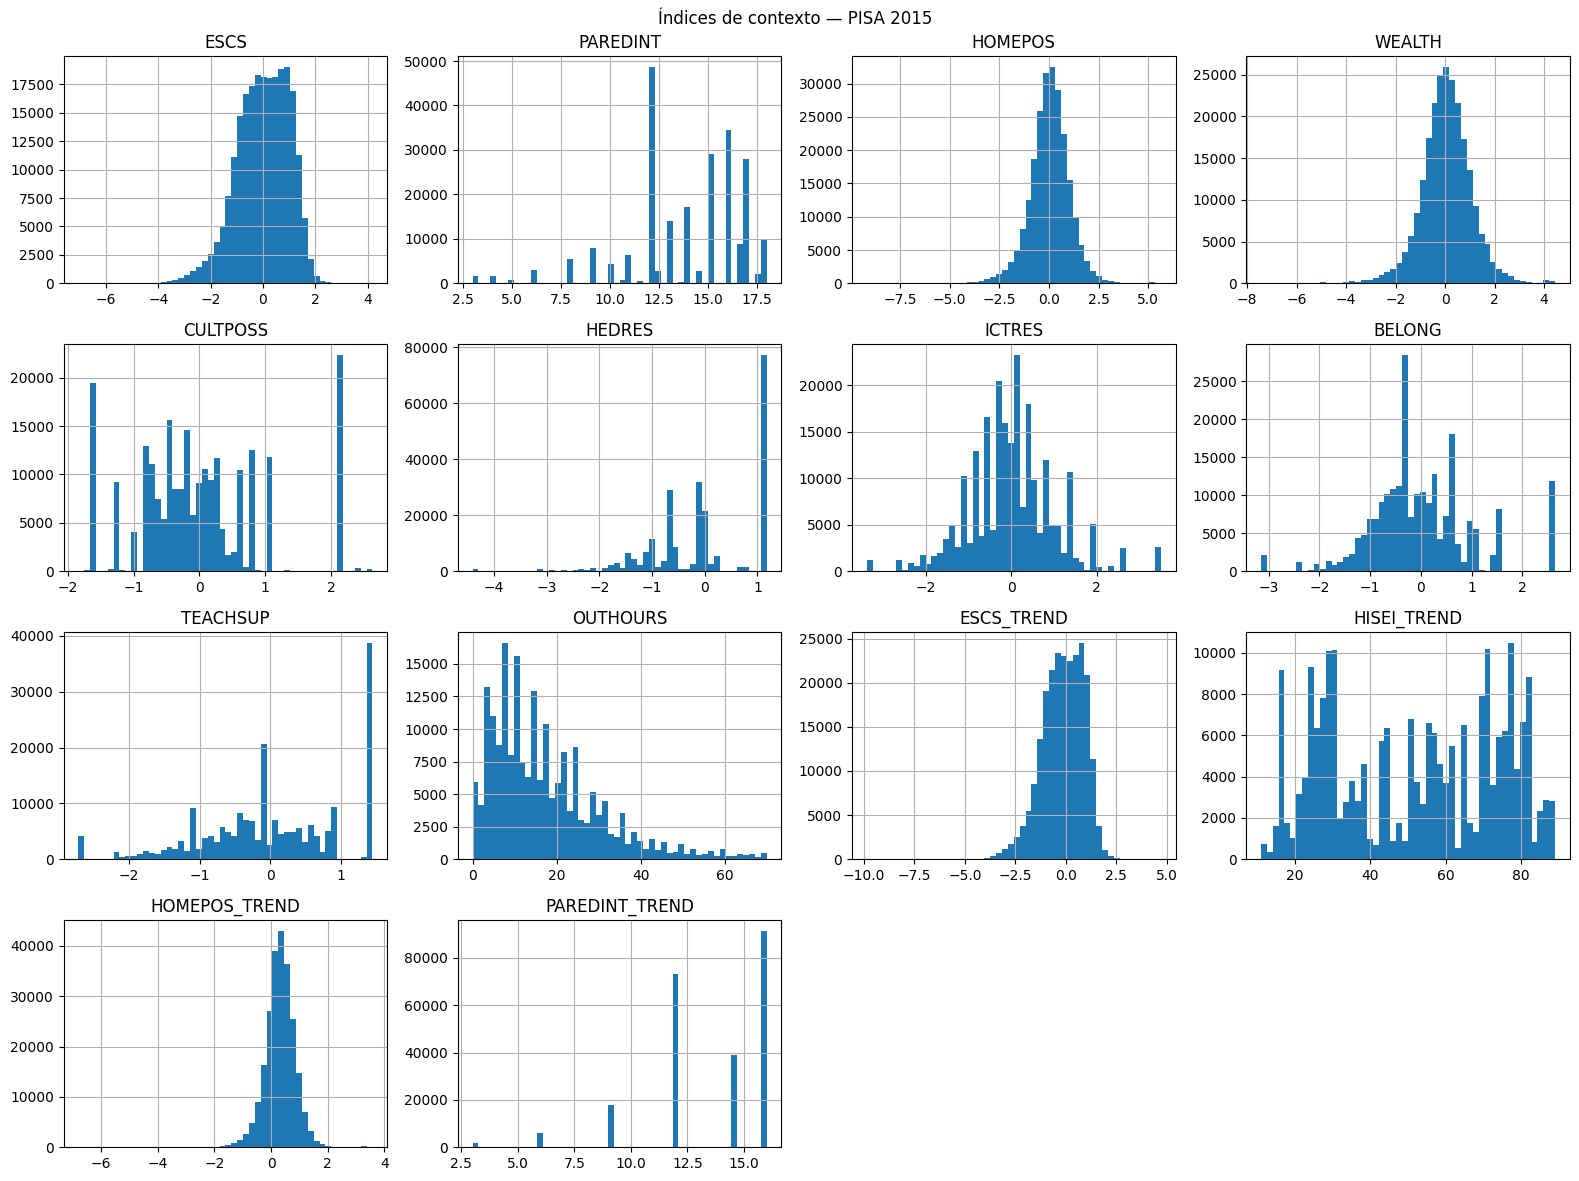

Suma de SENWT por país: mín 5000.00, máx 5000.00 (esperado 5000)


,W_FSTUWT,SENWT
count,238452.00,238452.00
mean,54.90,0.69
std,109.99,0.41
min,1.00,0.01
25%,8.71,0.42
50%,15.23,0.72
75%,59.02,0.91
max,2160.91,5.60


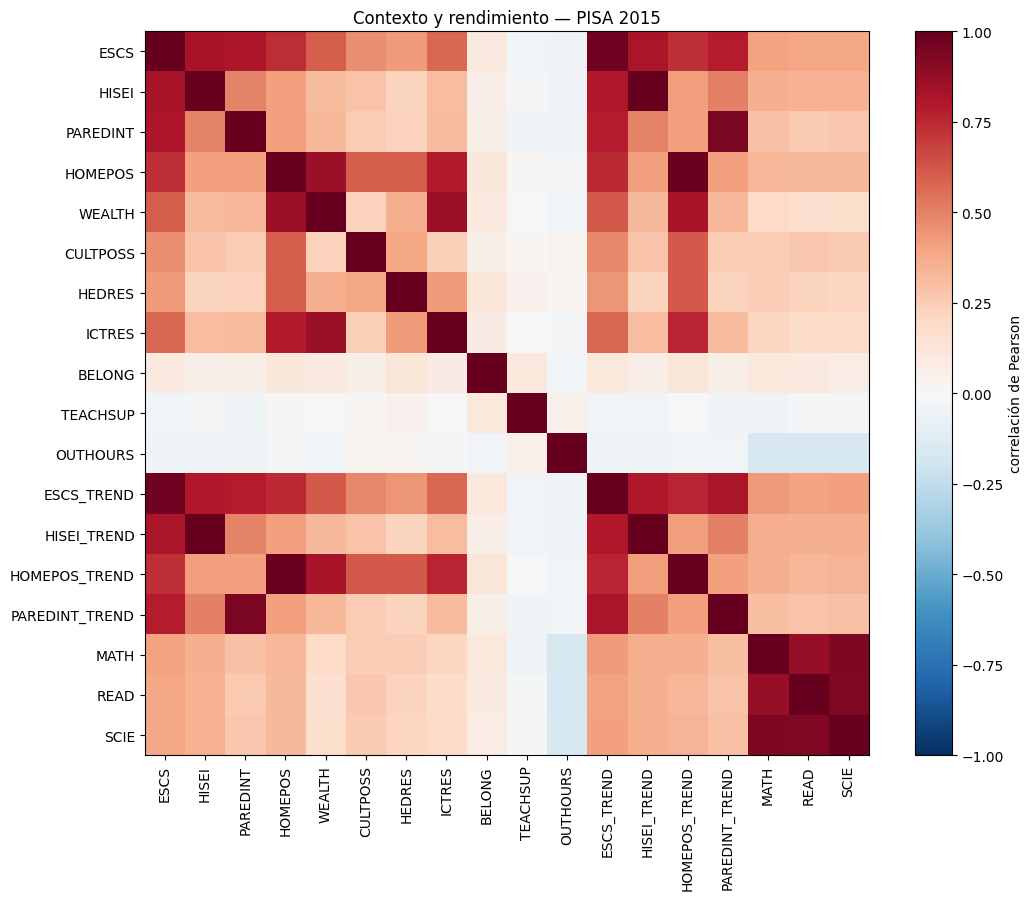

,perf_con_dato,perf_sin_dato,diferencia
variable,,,
HISEI,501.00,434.13,66.87
CULTPOSS,497.42,431.38,66.04
HEDRES,496.58,434.79,61.79
HISEI_TREND,499.41,438.77,60.64
BELONG,498.38,445.02,53.36
TEACHSUP,503.04,449.92,53.12
OUTHOURS,503.54,450.73,52.80
ICTRES,496.25,447.60,48.64
ESCS,496.29,448.47,47.82


Varianza del rendimiento (%):


,Entre países,Entre escuelas (dentro de país),Entre alumnos (dentro de escuela)
PISA 2015,7.00,33.30,59.70


In [5]:
eda_edicion(2015)

## 1.3 PISA 2018

### PISA 2018 (dominio principal: READ)

269,587 alumnos | 10,366 centros | 33 países


,% nulos alumnos,% nulos centros
BEINGBULLIED,24.80,NaN
BELONG,11.90,NaN
TEACHSUP,11.90,NaN
HISEI,8.10,NaN
HISEI_TREND,8.10,NaN
PAREDINT,4.60,NaN
PAREDINT_TREND,4.60,NaN
CULTPOSS,3.90,NaN
DISCLIMA,3.80,NaN
ESCS,3.40,NaN


alumnos  BEINGBULLIED    KOR (100%), ISR (100%), DEU (57%), MEX (47%), ...
         BELONG          ISR (100%), DEU (28%), MEX (24%), NLD (21%), A...
         TEACHSUP        CAN (100%), ISR (17%), DEU (14%), MEX (12%), A...
         HISEI           DEU (19%), AUS (15%), GBR (13%), MEX (13%), CA...
         HISEI_TREND     DEU (19%), AUS (15%), GBR (13%), MEX (13%), CA...
centros  STRATIO         AUT (100%), NOR (100%), CAN (100%), GBR (28%),...
         CLSIZE          CAN (100%), SWE (100%), DNK (26%), GBR (17%), ...
         SCHLTYPE        BEL (100%), SWE (100%), IRL (100%), NOR (100%)...
         STAFFSHORT      DNK (22%), GBR (19%), DEU (16%), FRA (15%), US...
         EDUSHORT        DNK (22%), GBR (19%), DEU (16%), FRA (15%), US...
Name: países con más nulos, dtype: object

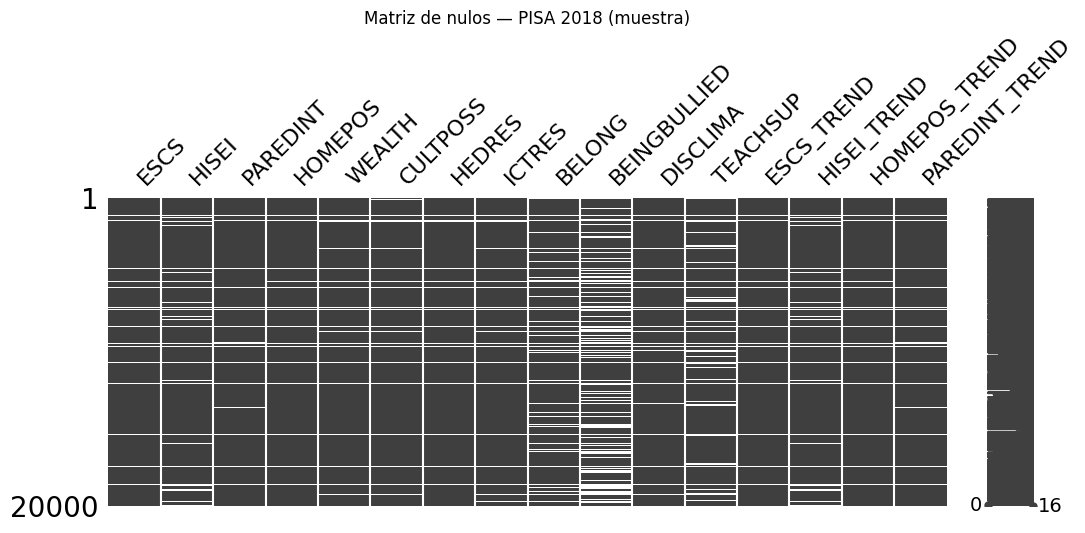

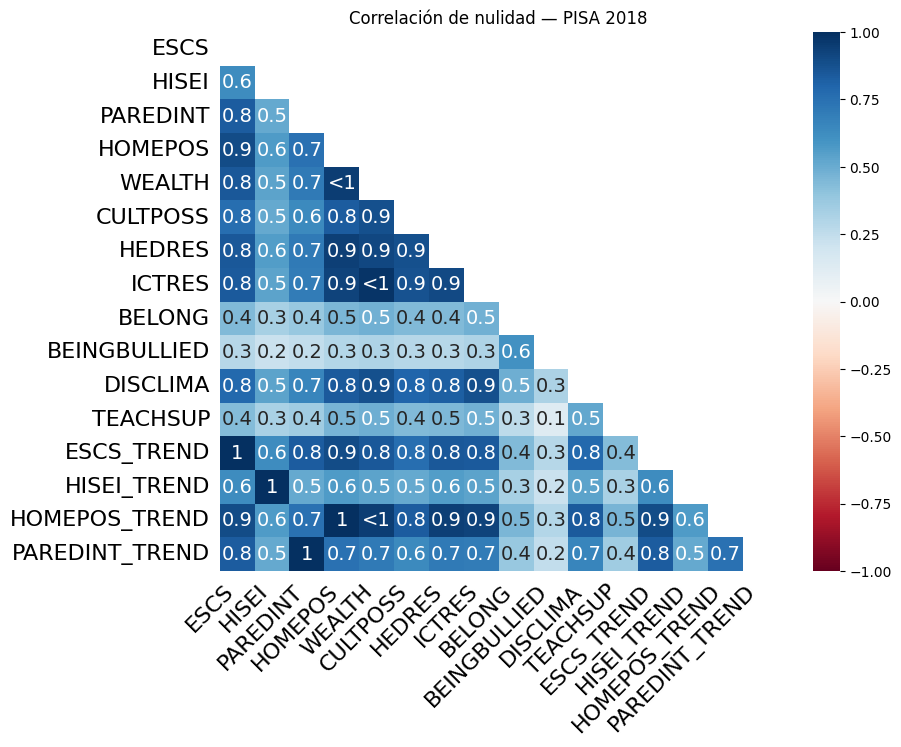

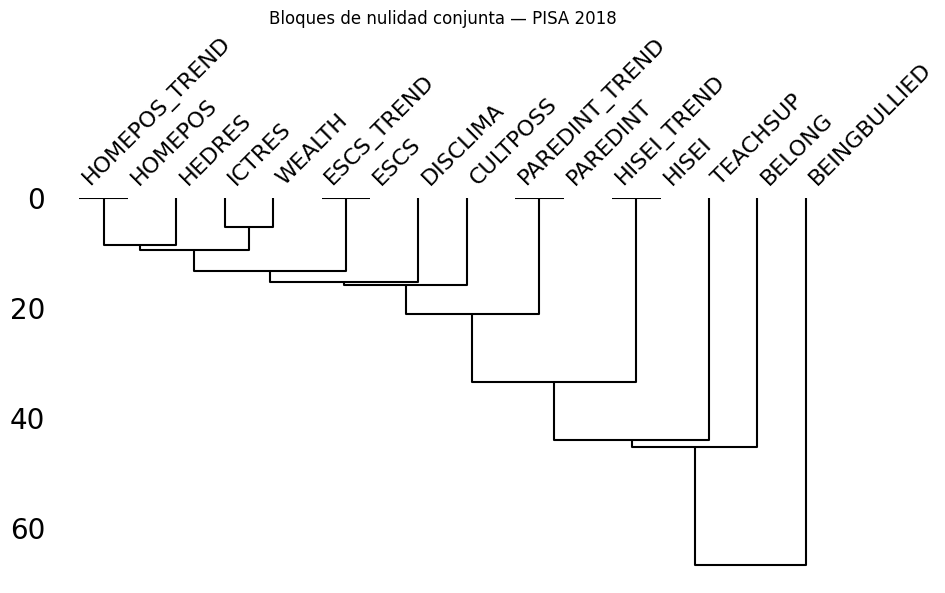

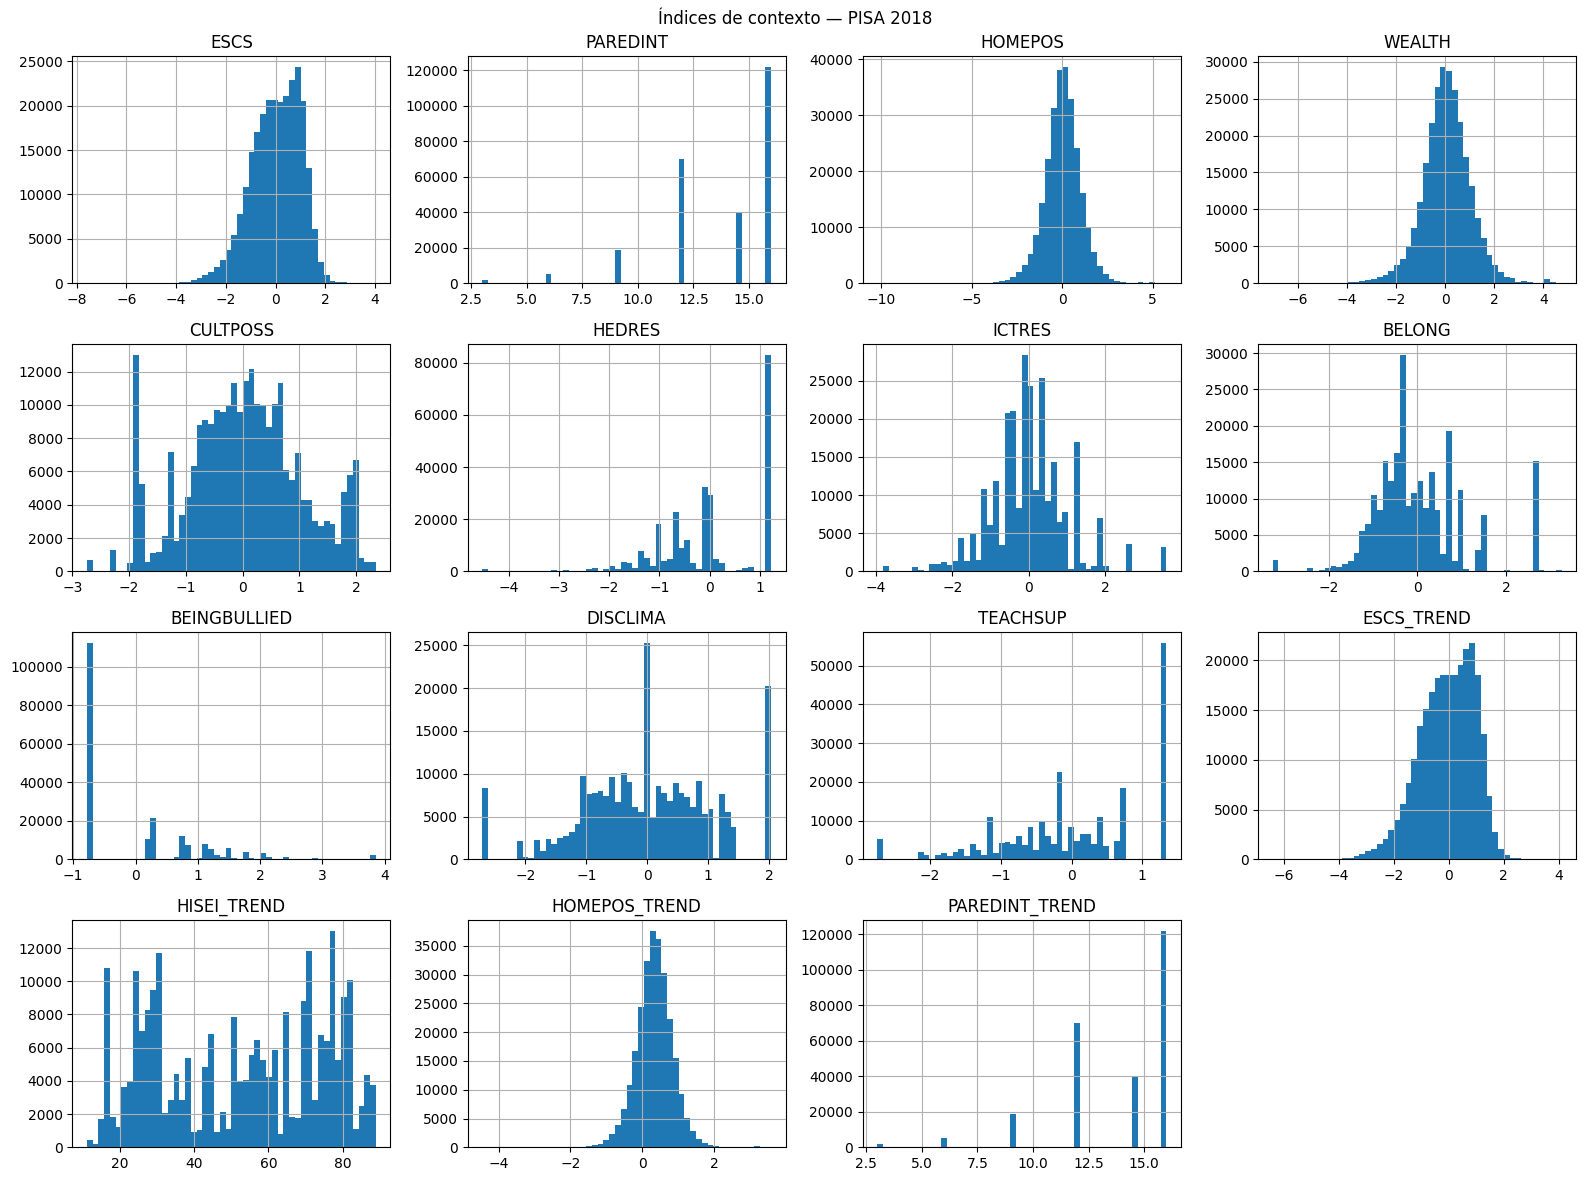

Suma de SENWT por país: mín 5000.00, máx 5000.00 (esperado 5000)


,W_FSTUWT,SENWT
count,269587.00,269587.00
mean,48.22,0.61
std,113.46,0.42
min,1.00,0.01
25%,7.33,0.22
50%,13.90,0.67
75%,37.61,0.85
max,2946.13,5.30


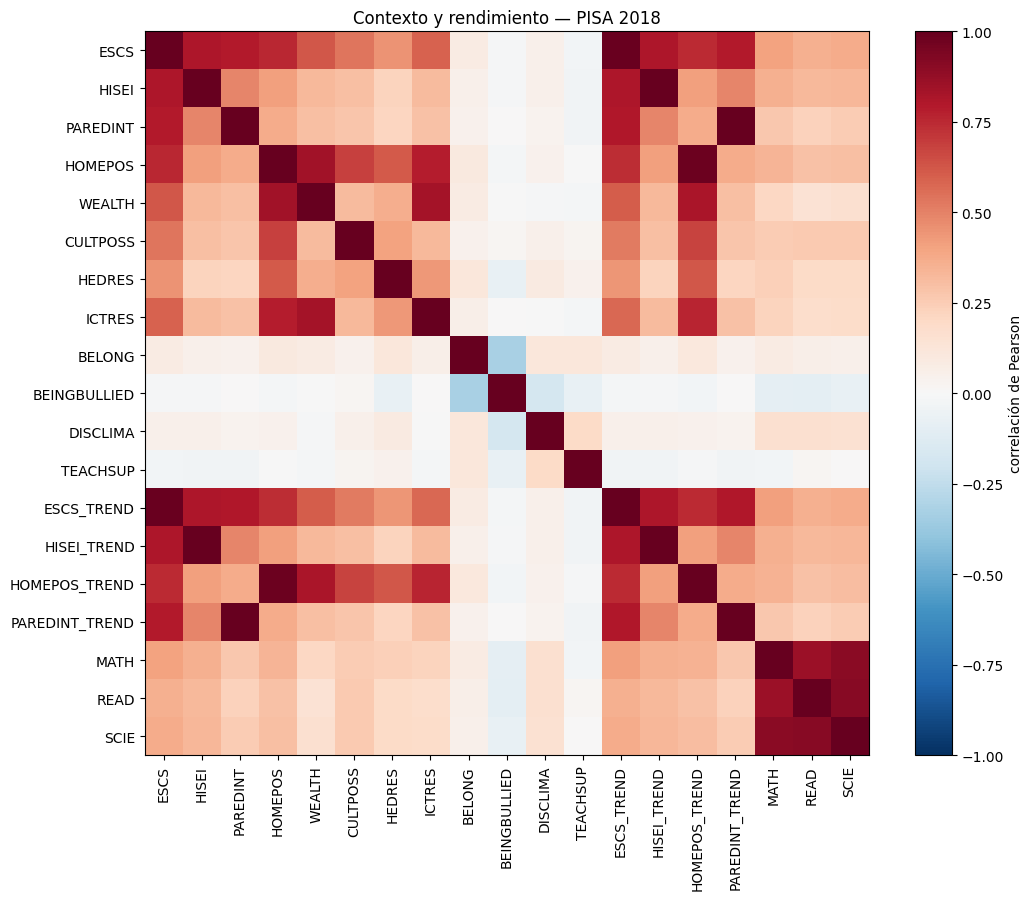

,perf_con_dato,perf_sin_dato,diferencia
variable,,,
HISEI,496.05,430.66,65.40
HISEI_TREND,496.05,430.66,65.40
DISCLIMA,492.93,434.25,58.69
BELONG,497.12,443.25,53.87
HEDRES,492.26,441.44,50.82
CULTPOSS,492.66,443.59,49.07
ESCS,492.29,446.17,46.12
ESCS_TREND,492.29,446.17,46.12
PAREDINT_TREND,492.78,448.54,44.24


Varianza del rendimiento (%):


,Entre países,Entre escuelas (dentro de país),Entre alumnos (dentro de escuela)
PISA 2018,3.80,31.70,64.50


In [6]:
eda_edicion(2018)

## 1.4 PISA 2022

### PISA 2022 (dominio principal: MATH)

268,610 alumnos | 10,131 centros | 33 países


,% nulos alumnos,% nulos centros
ICTRES,58.70,NaN
ICTDISTR,43.80,NaN
ICTWKEND,35.00,NaN
ICTWKDY,33.10,NaN
TEACHSUP,16.60,NaN
ANXMAT,15.10,NaN
MATHEFF,12.50,NaN
HISEI,10.40,NaN
HISEI_TREND,10.40,NaN
BELONG,7.90,NaN


alumnos  ICTRES            AUT (100%), SVN (100%), BEL (100%), CHE (100%)...
         ICTDISTR          CAN (100%), NZL (100%), FRA (100%), NOR (100%)...
         ICTWKEND          CAN (100%), NZL (100%), FRA (100%), NOR (100%)...
         ICTWKDY           CAN (100%), NZL (100%), FRA (100%), NOR (100%)...
         TEACHSUP          CAN (100%), ISR (21%), GBR (18%), DEU (17%), C...
         ANXMAT            ISR (100%), CHE (24%), GBR (22%), DEU (21%), D...
         MATHEFF           CHL (23%), DEU (22%), CHE (21%), GBR (20%), CA...
         HISEI             GBR (22%), DEU (20%), CAN (16%), FRA (14%), NL...
         HISEI_TREND       GBR (22%), DEU (20%), CAN (16%), FRA (14%), NL...
         BELONG            ISR (100%), GBR (14%), DEU (14%), CAN (13%), C...
         BEINGBULLIED      ISR (100%), GBR (14%), DEU (13%), CAN (13%), C...
         PAREDINT_TREND    GBR (18%), DEU (17%), NZL (11%), CAN (8%), NOR...
         PAREDINT          GBR (18%), DEU (17%), NZL (11%), CAN (8%), NOR...

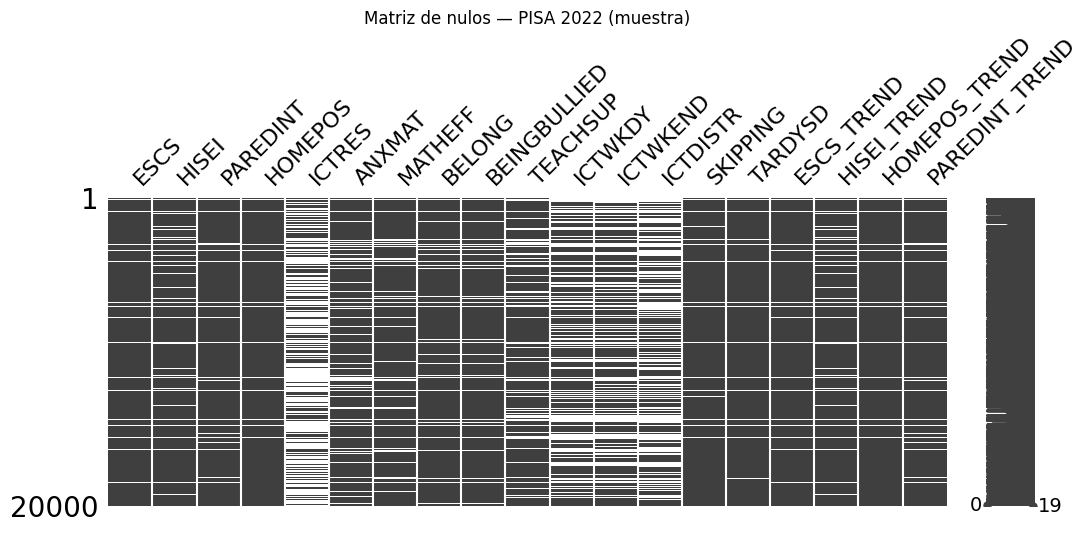

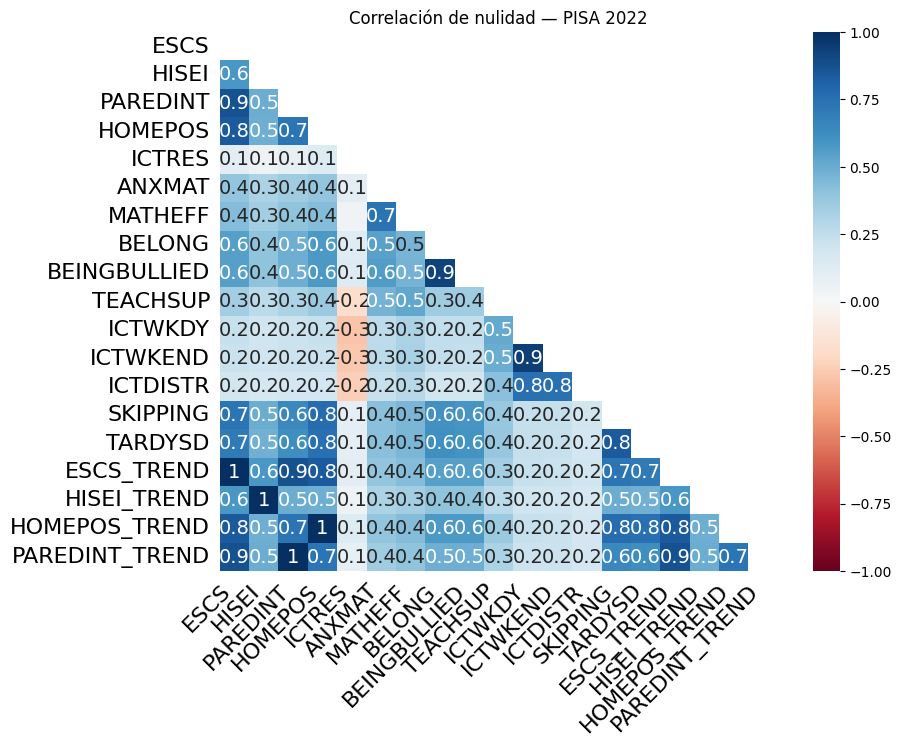

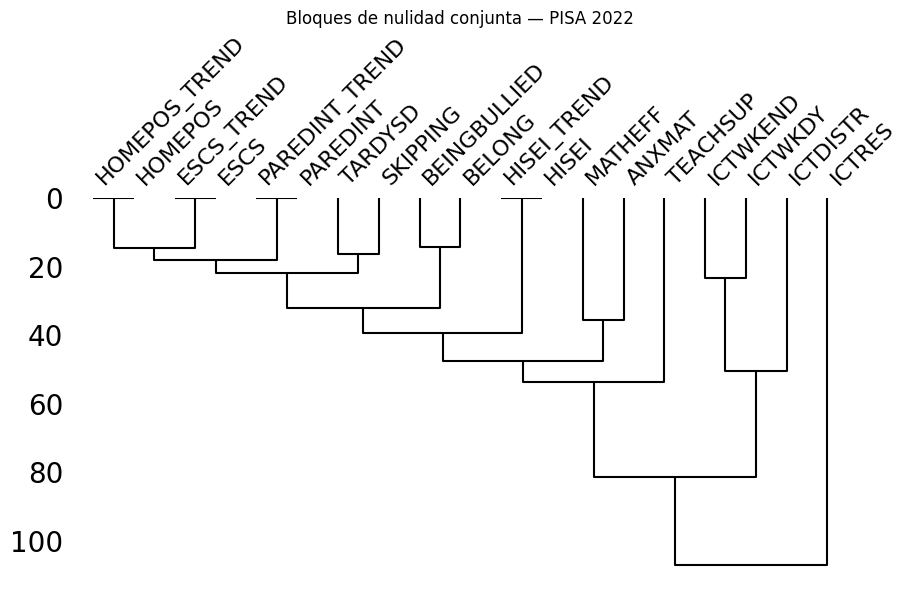

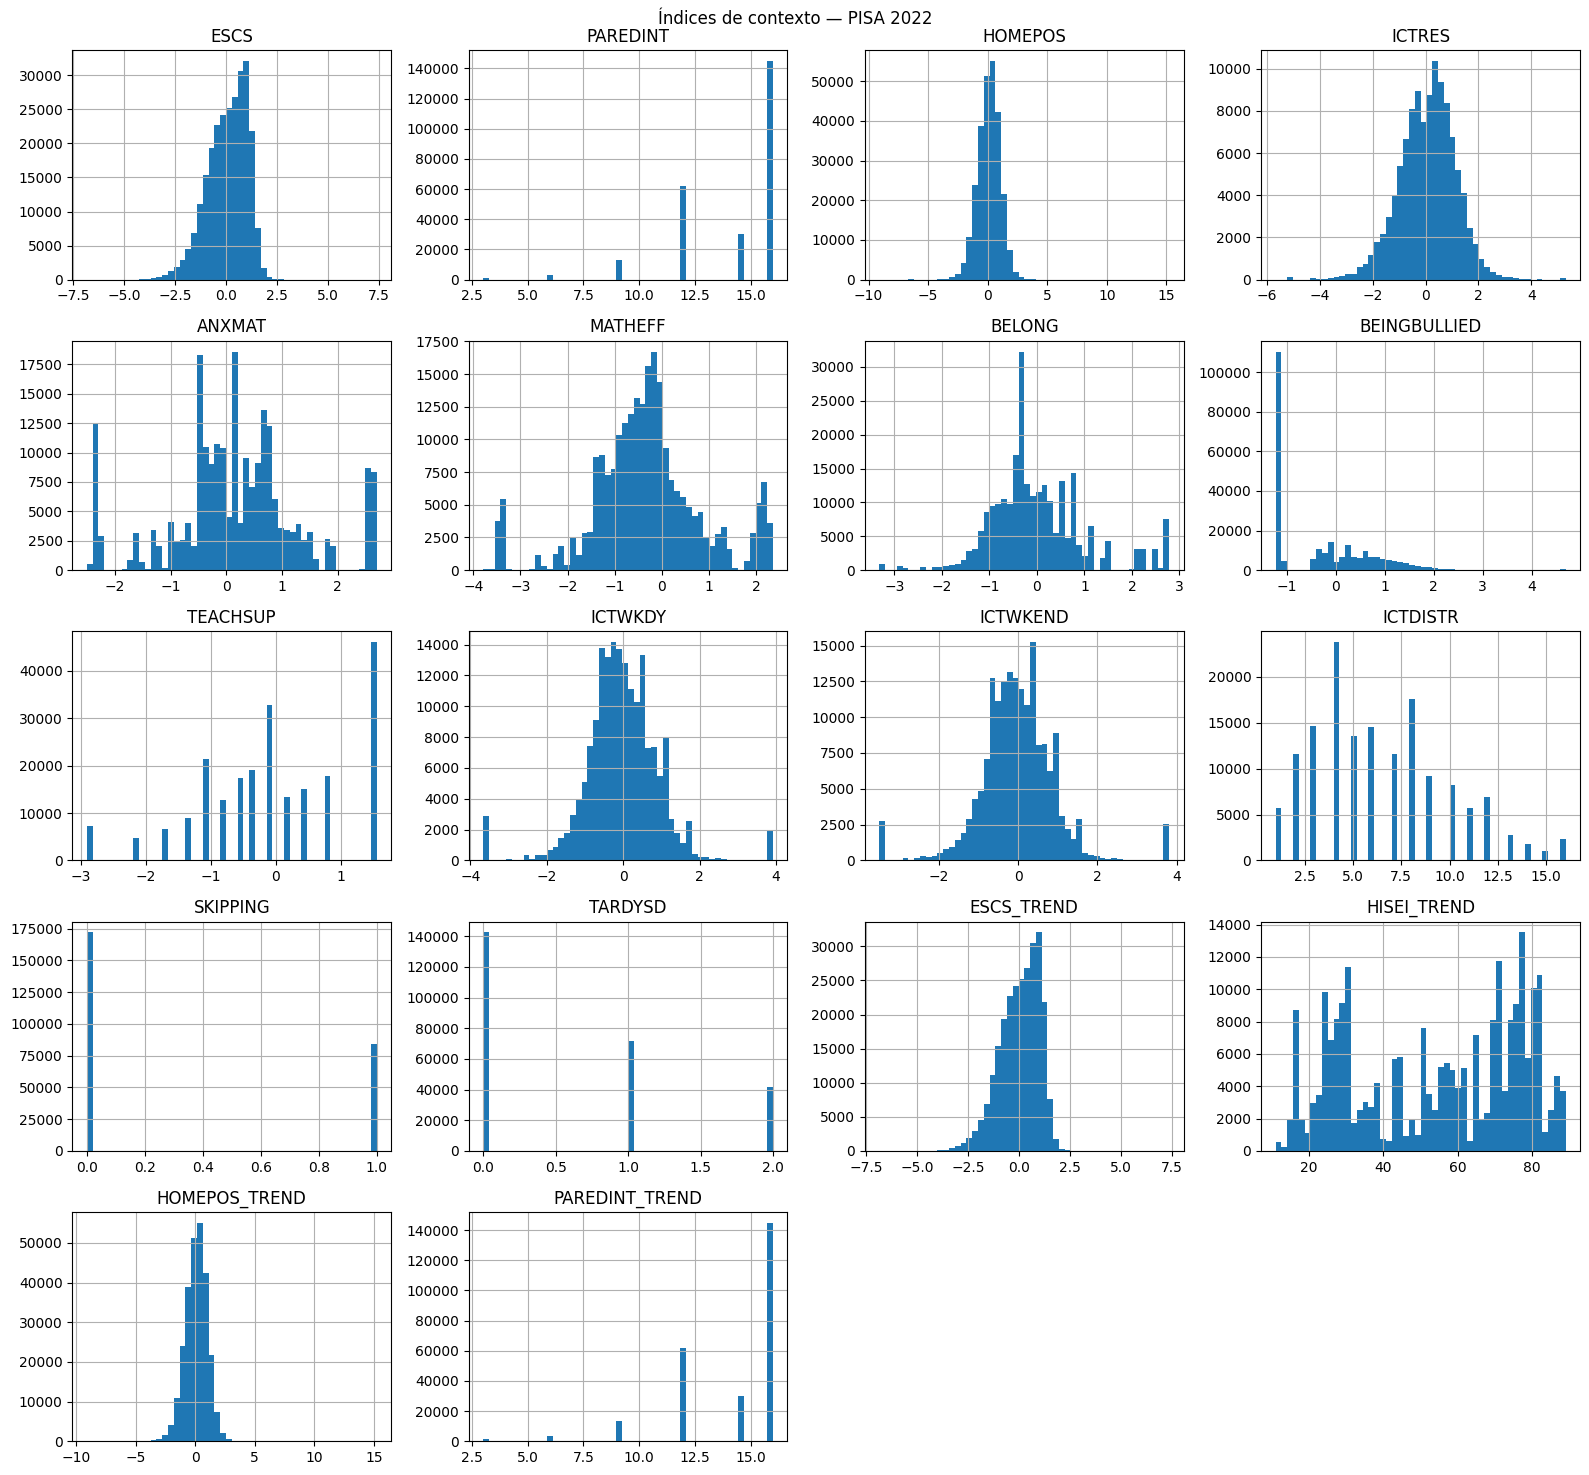

Suma de SENWT por país: mín 5000.00, máx 5000.01 (esperado 5000)


,W_FSTUWT,SENWT
count,268610.00,268610.00
mean,49.17,0.61
std,118.40,0.41
min,1.00,0.01
25%,7.88,0.29
50%,13.99,0.66
75%,39.92,0.82
max,2282.98,11.64


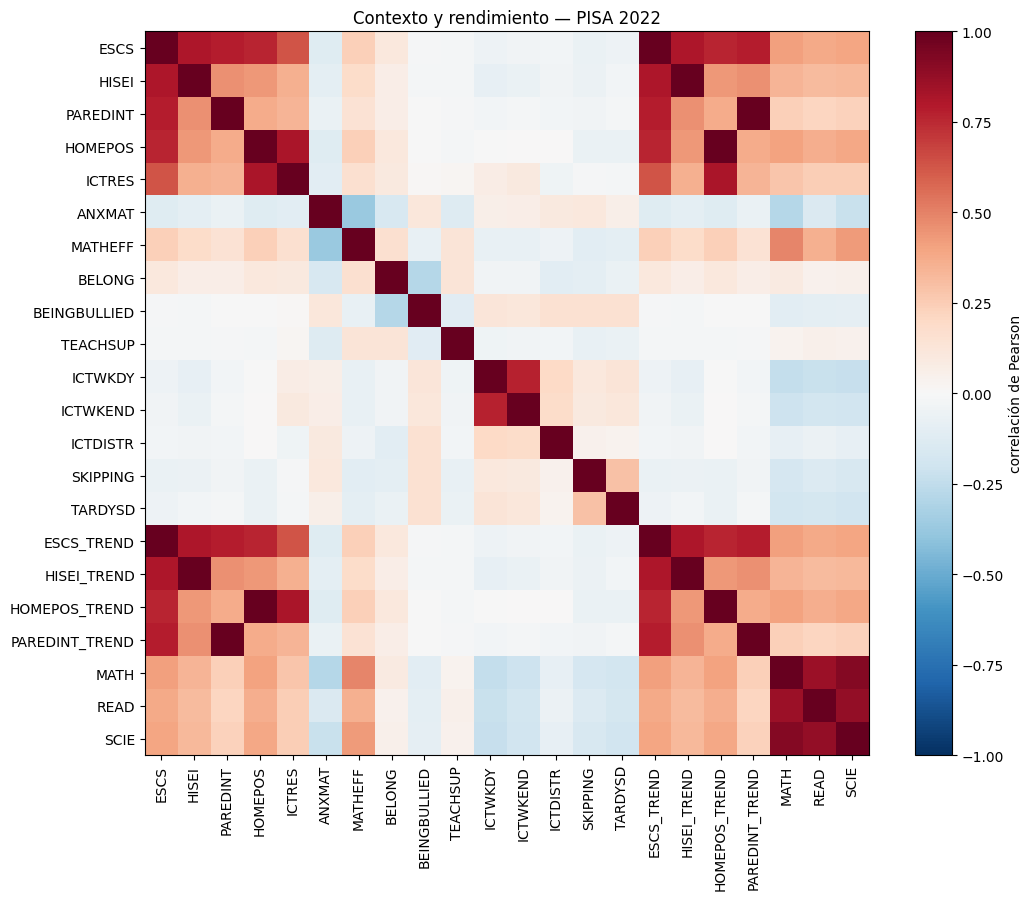

,perf_con_dato,perf_sin_dato,diferencia
variable,,,
MATHEFF,486.53,427.77,58.77
TARDYSD,481.81,426.92,54.89
HISEI_TREND,484.85,430.42,54.43
HISEI,484.85,430.42,54.43
SKIPPING,481.61,428.15,53.46
BELONG,483.23,431.97,51.26
BEINGBULLIED,483.20,432.07,51.13
ANXMAT,486.27,439.44,46.83
PAREDINT,481.31,439.43,41.87


Varianza del rendimiento (%):


,Entre países,Entre escuelas (dentro de país),Entre alumnos (dentro de escuela)
PISA 2022,6.60,33.00,60.30


In [7]:
eda_edicion(2022)

## 2. EDA conjunto

Comparación entre las cuatro ediciones.

### 2.1 Nulos por columna y edición

`NaN` = la columna no existe en esa edición. En 2012, `BELONG`, `ANXMAT`, `MATHEFF`, `TEACHSUP` y `DISCLIMA` tienen ~35% de nulos por la rotación de cuestionarios (cada alumno responde 2 de 3 bloques).

In [8]:
ctx_est = [c for c in COLUMNAS_CONTEXTO_ESTUDIANTE]
resumen_nulos = pd.DataFrame({
    año: porcentaje_nulos(estudiantes[año][[c for c in ctx_est if c in estudiantes[año].columns]])
    for año in EDICIONES
}).sort_values(by=EDICIONES[-1], ascending=False)
resumen_nulos.round(1)

,2012,2015,2018,2022
ICTRES,NaN,2.20,3.10,58.70
ICTDISTR,NaN,NaN,NaN,43.80
ICTWKEND,NaN,NaN,NaN,35.00
ICTWKDY,NaN,NaN,NaN,33.10
TEACHSUP,34.70,14.80,11.90,16.60
ANXMAT,34.90,NaN,NaN,15.10
MATHEFF,34.70,NaN,NaN,12.50
HISEI_TREND,5.00,7.00,8.10,10.40
HISEI,4.90,8.70,8.10,10.40
BELONG,35.00,6.00,11.90,7.90


### 2.2 Nulos en colegios

In [9]:
resumen_nulos_colegios = pd.DataFrame({
    año: porcentaje_nulos(colegios[año][[c for c in COLUMNAS_CONTEXTO_COLEGIO if c in colegios[año].columns]])
    for año in EDICIONES
}).sort_values(by=EDICIONES[-1], ascending=False)
resumen_nulos_colegios.round(1)

,2012,2015,2018,2022
STAFFSHORT,NaN,10.90,5.90,28.80
STRATIO,11.20,13.80,22.70,23.90
CLSIZE,4.90,10.20,15.90,20.60
PROPMATH,13.00,NaN,NaN,14.50
SCHLTYPE,4.80,15.20,12.00,12.80
EDUSHORT,NaN,10.70,5.70,10.60


### 2.3 Cobertura de países

Comprobación: deben salir los 33 países en las 4 ediciones.

In [10]:
paises_por_edicion = {año: set(estudiantes[año]['CNT'].unique()) for año in EDICIONES}
todos_los_paises = sorted(set.union(*paises_por_edicion.values()))
cobertura = pd.DataFrame({año: [p in paises_por_edicion[año] for p in todos_los_paises] for año in EDICIONES},
                         index=todos_los_paises)
cobertura['n_ediciones'] = cobertura[EDICIONES].sum(axis=1)
paises_completos = cobertura[cobertura['n_ediciones'] == len(EDICIONES)].index.tolist()
print(f'Países en las {len(EDICIONES)} ediciones: {len(paises_completos)} de {len(todos_los_paises)}')

Países en las 4 ediciones: 33 de 33


### 2.4 Países sin ningún dato real

Fracción de países con la columna 100% nula en cada edición. Son países que no administraron el módulo o cuya puntuación se suprimió; hay que excluirlos al usar esas variables.

In [11]:
UMBRAL_PAIS_SIN_DATO = 99.9   # % de nulos para decir que un país no tiene ningún dato


def paises_sin_dato(tablas, columnas):
    """Por columna y edición: lista de países cuyo % de nulos es >= UMBRAL_PAIS_SIN_DATO."""
    filas = {}
    for c in columnas:
        fila = {}
        for año in EDICIONES:
            df = tablas[año]
            if c not in df.columns:
                fila[año] = np.nan
                continue
            p = porcentaje_nulos_por_pais(df, c).set_index('CNT').iloc[:, 0]
            fila[año] = sorted(p[p >= UMBRAL_PAIS_SIN_DATO].index)
        filas[c] = fila
    return pd.DataFrame(filas).T


def resumen_paises(tabla):
    """% de países sin dato (o NaN si la columna no existe) por columna y edición."""
    return tabla.map(lambda x: np.nan if isinstance(x, float) else 100 * len(x) / len(paises_completos))


sin_dato_est = paises_sin_dato(estudiantes, [c for c in resumen_nulos.index if (resumen_nulos.loc[c] > UMBRAL_NULOS).any()])
sin_dato_col = paises_sin_dato(colegios, [c for c in resumen_nulos_colegios.index if (resumen_nulos_colegios.loc[c] > UMBRAL_NULOS).any()])
print('% de países sin ningún dato (alumnos):')
display(resumen_paises(sin_dato_est).round(1))
print('% de países sin ningún dato (centros):')
display(resumen_paises(sin_dato_col).round(1))

% de países sin ningún dato (alumnos):


,2012,2015,2018,2022
ICTRES,NaN,0.00,0.00,57.60
ICTDISTR,NaN,NaN,NaN,21.20
ICTWKEND,NaN,NaN,NaN,21.20
ICTWKDY,NaN,NaN,NaN,21.20
TEACHSUP,0.00,0.00,3.00,3.00
ANXMAT,0.00,NaN,NaN,3.00
MATHEFF,0.00,NaN,NaN,0.00
HISEI_TREND,3.00,0.00,0.00,0.00
HISEI,0.00,0.00,0.00,0.00
BELONG,0.00,3.00,3.00,3.00


% de países sin ningún dato (centros):


,2012,2015,2018,2022
STAFFSHORT,NaN,0.00,0.00,18.20
STRATIO,0.00,0.00,9.10,6.10
CLSIZE,0.00,0.00,6.10,6.10
PROPMATH,0.00,NaN,NaN,3.00
SCHLTYPE,0.00,3.00,12.10,12.10
EDUSHORT,NaN,0.00,0.00,0.00


In [12]:
# Qué países son, para las columnas con alguno
for nombre, tabla in (('alumnos', sin_dato_est), ('centros', sin_dato_col)):
    for c in tabla.index:
        for año in EDICIONES:
            lista = tabla.loc[c, año]
            if not isinstance(lista, float) and lista:
                print(f'{nombre} · {c} · {año}: {lista}')

alumnos · ICTRES · 2022: ['AUT', 'BEL', 'CHE', 'CZE', 'DNK', 'ESP', 'EST', 'FIN', 'GRC', 'HUN', 'ISL', 'ISR', 'ITA', 'JPN', 'KOR', 'NLD', 'NOR', 'POL', 'SVN']
alumnos · ICTDISTR · 2022: ['CAN', 'FRA', 'MEX', 'NLD', 'NOR', 'NZL', 'PRT']
alumnos · ICTWKEND · 2022: ['CAN', 'FRA', 'MEX', 'NLD', 'NOR', 'NZL', 'PRT']
alumnos · ICTWKDY · 2022: ['CAN', 'FRA', 'MEX', 'NLD', 'NOR', 'NZL', 'PRT']
alumnos · TEACHSUP · 2018: ['CAN']
alumnos · TEACHSUP · 2022: ['CAN']
alumnos · ANXMAT · 2022: ['ISR']
alumnos · HISEI_TREND · 2012: ['AUT']
alumnos · BELONG · 2015: ['ISR']
alumnos · BELONG · 2018: ['ISR']
alumnos · BELONG · 2022: ['ISR']
alumnos · BEINGBULLIED · 2018: ['ISR', 'KOR']
alumnos · BEINGBULLIED · 2022: ['ISR']
centros · STAFFSHORT · 2022: ['BEL', 'CAN', 'EST', 'JPN', 'KOR', 'SVK']
centros · STRATIO · 2018: ['AUT', 'CAN', 'NOR']
centros · STRATIO · 2022: ['CAN', 'NOR']
centros · CLSIZE · 2018: ['CAN', 'SWE']
centros · CLSIZE · 2022: ['CAN', 'NOR']
centros · PROPMATH · 2022: ['NOR']
centros · 

### 2.5 Índices originales y `_TREND`

Media ponderada con `SENWT` (cada país pesa igual) de los índices originales y de sus versiones reescaladas. Los originales se estandarizan en cada ciclo (media ~0); las `_TREND` de 2012-2018 están en la escala de 2022. En 2022 son copia de los originales.

EDICION,2012,2015,2018,2022
indice,,,,
ESCS,-0.00,-0.03,-0.00,0.03
ESCS_TREND,-0.23,-0.16,-0.07,0.03
HISEI,50.71,51.92,52.55,54.03
HISEI_TREND,50.25,51.29,52.55,54.03
HOMEPOS,-0.01,-0.01,0.00,0.06
HOMEPOS_TREND,0.30,0.31,0.32,0.06
PAREDINT,13.49,13.75,13.82,14.21
PAREDINT_TREND,13.26,13.50,13.82,14.21


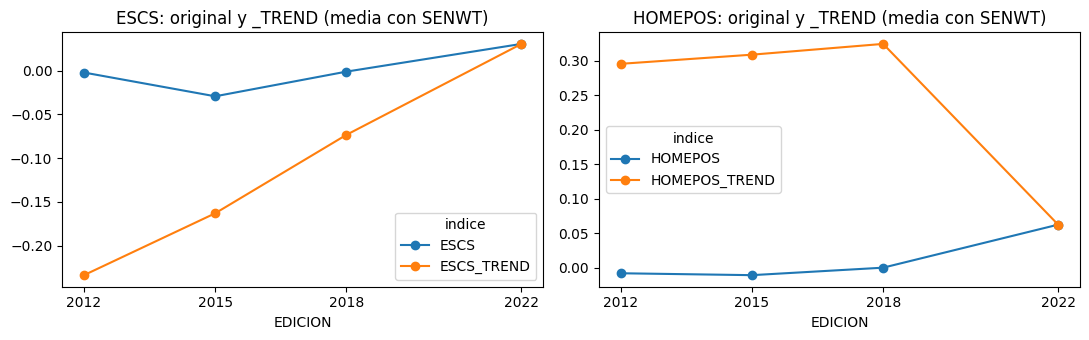

In [13]:
filas = []
for año in EDICIONES:
    est = estudiantes[año]
    for c in ('ESCS', 'HOMEPOS', 'HISEI', 'PAREDINT'):
        for col in (c, f'{c}_TREND'):
            x = est[[col, 'SENWT']].dropna()
            filas.append({'EDICION': año, 'indice': col, 'media': np.average(x[col], weights=x['SENWT'])})
medias_indices = pd.DataFrame(filas).pivot(index='indice', columns='EDICION', values='media')
display(medias_indices.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for c, a in zip(('ESCS', 'HOMEPOS'), ax):
    medias_indices.loc[[c, f'{c}_TREND']].T.plot(marker='o', ax=a, title=f'{c}: original y _TREND (media con SENWT)')
    a.set_xticks(EDICIONES)
plt.tight_layout()
plt.show()

### 2.6 Rendimiento por país y dominio

Tabla de las medias de cada edición (sección 1), guardada para el análisis posterior, y evolución de los 33 países.

In [14]:
df_rendimiento = pd.concat(rendimiento_por_edicion, ignore_index=True)
ruta_out = os.path.join(RUTA_INTERMEDIOS, 'pisa_multiedicion_rendimiento_pais_dominio.parquet')
df_rendimiento.to_parquet(ruta_out, index=False)   # tabla pequeña: se versiona en git
print(f'Guardado: {ruta_out} ({len(df_rendimiento)} filas)')

fig = px.line(
    df_rendimiento[df_rendimiento['CNT'].isin(paises_completos)].sort_values('EDICION'),
    x='EDICION', y='media_pv', color='CNT', facet_col='DOMINIO', markers=True,
    title=f'Evolución del rendimiento medio por país ({len(paises_completos)} países)',
    labels={'media_pv': 'Puntuación media (PV)', 'EDICION': 'Edición'},
)
fig.update_layout(height=550)
fig.show()

Guardado: ../../data/intermediate\pisa_multiedicion_rendimiento_pais_dominio.parquet (396 filas)


### 2.7 Estructura multinivel

In [15]:
pd.DataFrame(varianza_por_edicion).T.round(1)

,Entre países,Entre escuelas (dentro de país),Entre alumnos (dentro de escuela)
2012,11.70,35.30,53.10
2015,7.00,33.30,59.70
2018,3.80,31.70,64.50
2022,6.60,33.00,60.30


## Hallazgos del EDA

* **Nulos por diseño en 2012**: `BELONG`, `ANXMAT`, `MATHEFF`, `TEACHSUP`, `DISCLIMA` y `OUTHOURS` rondan el 35% por la rotación de cuestionarios; no es no-respuesta.
* **Módulos solo parciales**: en 2022 faltan por completo `ICTRES` en 19 de 33 países y `ICTWKDY`/`ICTWKEND`/`ICTDISTR` en 7. `BEINGBULLIED` tiene un 25% de nulos en 2018.
* **Centros**: `STAFFSHORT` falta en el 29% de los centros de 2022 (6 países sin dato); `STRATIO` y `CLSIZE` hasta en el 24%; `SCHLTYPE` entre el 12% y el 15% desde 2015.
* **Índices originales y `_TREND`**: los originales se estandarizan en cada ciclo (media ~0 con `SENWT`). `ESCS_TREND` sube de −0,23 (2012) a +0,03 (2022) y `HISEI_TREND`/`PAREDINT_TREND` también; `HOMEPOS_TREND` (+0,30 a +0,32) no enlaza con `HOMEPOS` de 2022 (+0,06).
* **`HISEI_TREND` 2012**: Austria no tiene ningún valor (el `HISEI` original sí, con un 4% de nulos).
* **Varianza del rendimiento** (sin ponderar): entre países 11,7% (2012), 7,0%, 3,8% y 6,6% (2022); entre escuelas 32-35%; entre alumnos 53-65%.
* La tabla `pisa_multiedicion_rendimiento_pais_dominio.parquet` se regenera aquí.